# 🧠 SentinelAI - Model Training

This notebook trains an image classification model to detect malpractice events.

### Objectives:
- Load dataset
- Train deep learning model
- Track performance
- Save trained model

In [5]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

In [6]:
BASE_PATH = "../../"

DATA_DIR = os.path.join(BASE_PATH, "dataset/images")
MODEL_DIR = os.path.join(BASE_PATH, "models/classifier")
RESULTS_DIR = os.path.join(BASE_PATH, "experiments/results")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# Training Config
BATCH_SIZE = 16
EPOCHS = 5
LR = 0.001

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)

Device: cpu


In [7]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

In [ ]:
dataset = datasets.ImageFolder(DATA_DIR, transform=transform)

print("Classes:", dataset.classes)
print("Total Samples:", len(dataset))

In [5]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

print("Train:", len(train_dataset), "Validation:", len(val_dataset))

Train: 996 Validation: 249


In [6]:
model = models.resnet18(pretrained=True)

# Replace final layer
model.fc = nn.Linear(model.fc.in_features, len(dataset.classes))

model = model.to(DEVICE)

c:\Users\DELL\Desktop\sentinel-ai\sentinel-ai\venv\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\DELL\Desktop\sentinel-ai\sentinel-ai\venv\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

In [8]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0
    correct = 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()

    acc = correct / len(loader.dataset)
    loss = total_loss / len(loader)

    return loss, acc

In [9]:
def validate(model, loader):
    model.eval()
    correct = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()

    return correct / len(loader.dataset)

In [10]:
train_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_acc = validate(model, val_loader)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")
    print("-" * 30)

Epoch 1/5
Train Loss: 0.4186
Train Accuracy: 0.8685
Validation Accuracy: 0.7390
------------------------------
Epoch 2/5
Train Loss: 0.0149
Train Accuracy: 1.0000
Validation Accuracy: 1.0000
------------------------------
Epoch 3/5
Train Loss: 0.0156
Train Accuracy: 0.9990
Validation Accuracy: 1.0000
------------------------------
Epoch 4/5
Train Loss: 0.0584
Train Accuracy: 0.9849
Validation Accuracy: 0.8916
------------------------------
Epoch 5/5
Train Loss: 0.0056
Train Accuracy: 1.0000
Validation Accuracy: 1.0000
------------------------------


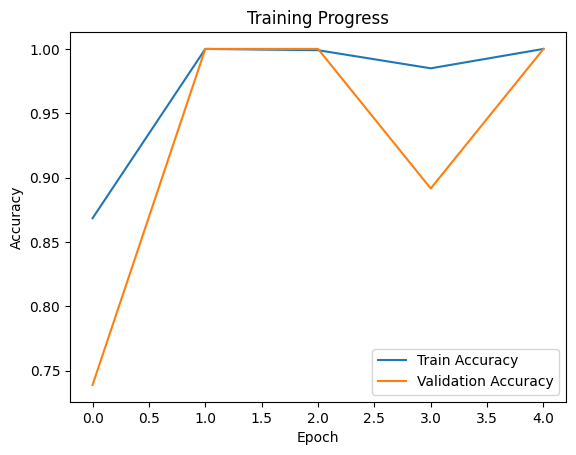

In [11]:
plt.figure()

plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.title("Training Progress")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [12]:
model_path = os.path.join(MODEL_DIR, "model_latest.pth")
torch.save(model.state_dict(), model_path)

print("✅ Model saved at:", model_path)

✅ Model saved at: ../../models/classifier\model_latest.pth


In [13]:
import json

metrics = {
    "train_accuracy": train_accuracies[-1],
    "val_accuracy": val_accuracies[-1],
    "epochs": EPOCHS
}

metrics_path = os.path.join(RESULTS_DIR, "training_metrics.json")

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=4)

print("✅ Training metrics saved")

✅ Training metrics saved
